# BayesianAIME — Explanation Uncertainty with 95% Intervals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ntakafumi/aime/blob/main/examples/colab/03_bayesian_aime_uncertainty.ipynb)

BayesianAIME estimates a mean inverse operator together with covariance information. The plotting and tabular APIs then expose **95% interval bounds** for global and local explanations.

This notebook demonstrates:

- global feature weights with interval whiskers,
- a local explanation with interval bounds,
- programmatic access to `mean / lower_bound / upper_bound`, and
- how the interval width changes with the calibration-sample count.

**Interpretation note:** in `aime-xai==1.2.0`, the prior mean is derived from ordinary AIME on the same data. The intervals are therefore best read as a regularized empirical-Bayes uncertainty proxy, not as universally calibrated posterior coverage.


## 0. Install and import


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("aime_xai") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "aime-xai==1.2.0"
    ])


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

import aime_xai
from aime_xai import AIME
import aime_xai.style as S

S.set_publication_mode(False)
print("aime_xai version:", aime_xai.__version__)


aime_xai version: 1.2.0


## 1. Train a black-box classifier

We use scikit-learn's built-in Breast Cancer Wisconsin dataset so the notebook needs no external data download.


In [3]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data.astype(float)
y = dataset.target.astype(int)
feature_names = X.columns.tolist()
class_names = dataset.target_names.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

y_hat_train = model.predict_proba(X_train)
y_hat_test = model.predict_proba(X_test)

metrics = pd.Series({
    "test accuracy": accuracy_score(y_test, model.predict(X_test)),
    "test ROC AUC for class 1": roc_auc_score(y_test, y_hat_test[:, 1]),
})
display(metrics.to_frame("value").round(3))


,value
test accuracy,0.958
test ROC AUC for class 1,0.993


## 2. Fit BayesianAIME

`bayesian_sigma` controls the assumed likelihood-noise scale and `bayesian_tau` controls the prior scale. The values below are illustrative and chosen to make interval widths visible in a compact demo.


In [4]:
BAYESIAN_SIGMA = 0.5
BAYESIAN_TAU = 1.0

bayes = AIME(
    use_bayesian=True,
    bayesian_sigma=BAYESIAN_SIGMA,
    bayesian_tau=BAYESIAN_TAU,
).create_explainer(X_train, y_hat_train, normalize=True)

print("variant:", bayes.variant_name)
print("posterior-mean A† shape:", bayes.A_dagger.shape)
print("class-space covariance shape:", bayes.A_dagger_cov.shape)


variant: BayesianAIME
posterior-mean A† shape: (30, 2)
class-space covariance shape: (2, 2)


## 3. Global explanations with 95% interval whiskers

The returned DataFrame has a two-level column index: `(feature, statistic)`, where the statistic is `mean`, `lower_bound`, or `upper_bound`.


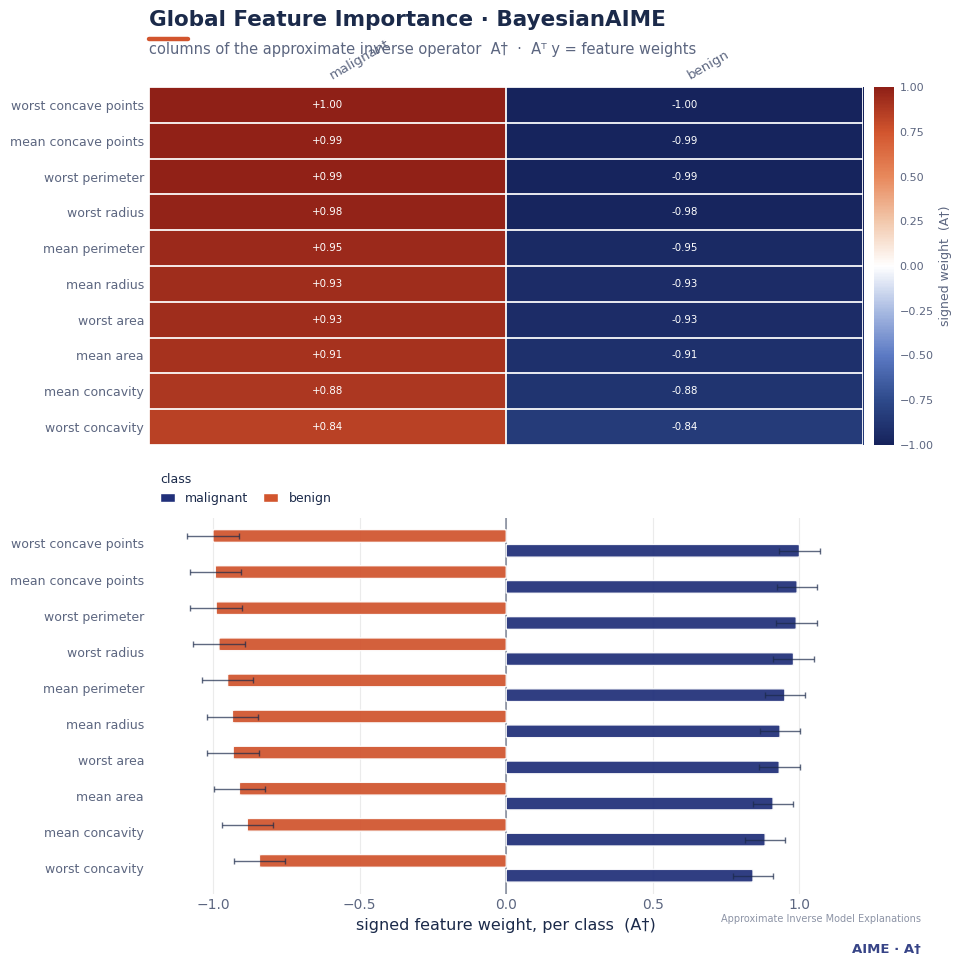

returned shape: (2, 30)
column levels: [None, None]


In [5]:
global_ci = bayes.global_feature_importance(
    feature_names=feature_names,
    class_names=class_names,
    top_k=10,
    layout="vertical",
)

print("returned shape:", global_ci.shape)
print("column levels:", global_ci.columns.names)


In [6]:
global_mean = global_ci.xs("mean", level=1, axis=1)
global_lower = global_ci.xs("lower_bound", level=1, axis=1)
global_upper = global_ci.xs("upper_bound", level=1, axis=1)

inspected_class = class_names[1]
inspected_features = global_mean.loc[inspected_class].abs().nlargest(8).index
global_table = pd.DataFrame({
    "mean": global_mean.loc[inspected_class, inspected_features],
    "lower_bound": global_lower.loc[inspected_class, inspected_features],
    "upper_bound": global_upper.loc[inspected_class, inspected_features],
})

print("class:", inspected_class)
display(global_table.round(3))


class: benign


,mean,lower_bound,upper_bound
worst concave points,-1.000,-1.088,-0.912
mean concave points,-0.992,-1.080,-0.904
worst perimeter,-0.989,-1.077,-0.901
worst radius,-0.980,-1.067,-0.892
mean perimeter,-0.950,-1.038,-0.862
mean radius,-0.934,-1.021,-0.846
worst area,-0.931,-1.019,-0.843
mean area,-0.910,-0.998,-0.822


## 4. Local explanation with interval bounds

We explain the test point with the highest predictive entropy, which is the model's least decisive case in this split.


,probability
malignant,0.487
benign,0.513


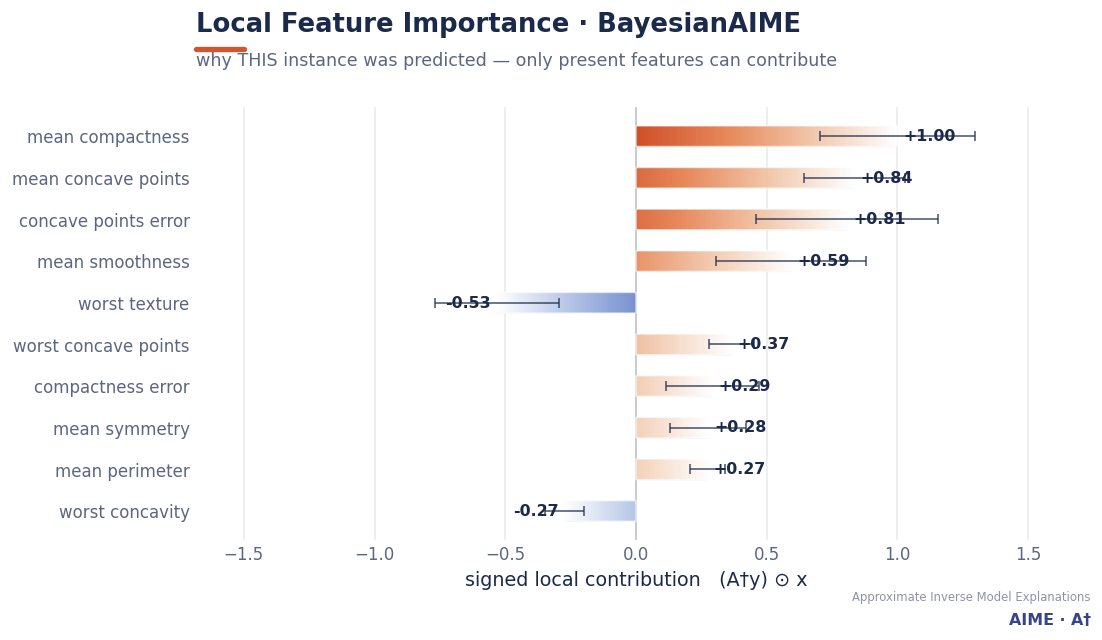

,mean compactness,mean concave points,concave points error,mean smoothness,worst texture,worst concave points,compactness error,mean symmetry,mean perimeter,worst concavity
mean,1.000,0.836,0.808,0.595,-0.532,0.366,0.292,0.277,0.274,-0.274
lower_bound,0.704,0.641,0.461,0.308,-0.768,0.281,0.115,0.131,0.208,-0.349
upper_bound,1.296,1.030,1.156,0.882,-0.296,0.450,0.470,0.422,0.341,-0.199


In [7]:
entropy = -(y_hat_test * np.log(np.clip(y_hat_test, 1e-12, 1.0))).sum(axis=1)
focus_position = int(np.argmax(entropy))
focus_x = X_test.iloc[focus_position].to_numpy(dtype=float)
focus_y = y_hat_test[focus_position]

display(pd.Series(focus_y, index=class_names, name="probability").to_frame().round(3))

local_ci = bayes.local_feature_importance(
    focus_x,
    focus_y,
    feature_names=feature_names,
    scaler=bayes.scaler,
    top_k=10,
    ignore_zero_features=False,
)

display(local_ci.round(3))


## 5. Interval width versus calibration-sample count

The following diagnostic repeatedly fits BayesianAIME to subsets of the same black-box model outputs. For the normalized global weights, the full 95% interval width for class `c` is

`2 × 1.96 × sqrt(cov[c,c]) / max(|A†[:,c]|)`.

This is a diagnostic of the fitted uncertainty model, not a benchmark claim.


,calibration samples,mean normalized 95% interval width
0,60,0.400
1,150,0.265
2,426,0.157


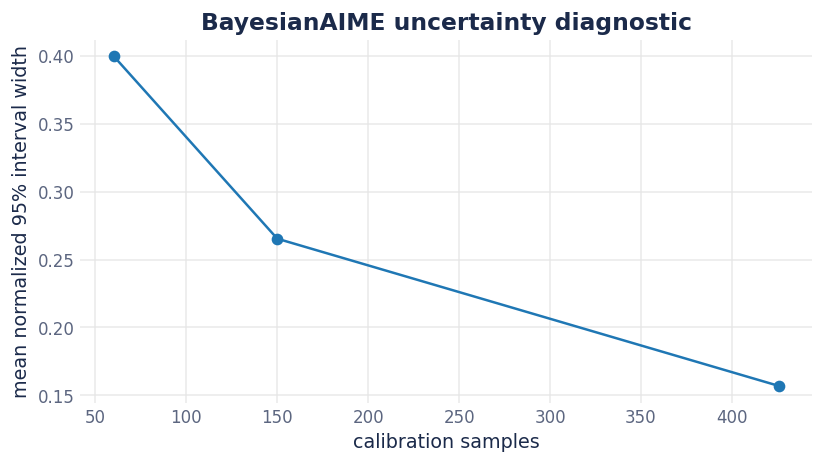

In [8]:
rng = np.random.default_rng(42)
sample_sizes = [60, 150, len(X_train)]
width_rows = []

for sample_size in sample_sizes:
    if sample_size < len(X_train):
        positions = rng.choice(len(X_train), size=sample_size, replace=False)
    else:
        positions = np.arange(len(X_train))

    X_cal = X_train.iloc[positions]
    Y_cal = model.predict_proba(X_cal)

    fitted = AIME(
        use_bayesian=True,
        bayesian_sigma=BAYESIAN_SIGMA,
        bayesian_tau=BAYESIAN_TAU,
    ).create_explainer(X_cal, Y_cal, normalize=True)

    class_widths = []
    for class_index in range(fitted.A_dagger.shape[1]):
        normalizer = np.max(np.abs(fitted.A_dagger[:, class_index])) or 1.0
        standard_deviation = np.sqrt(
            max(float(fitted.A_dagger_cov[class_index, class_index]), 0.0)
        )
        class_widths.append(2.0 * 1.96 * standard_deviation / normalizer)

    width_rows.append({
        "calibration samples": sample_size,
        "mean normalized 95% interval width": float(np.mean(class_widths)),
    })

width_table = pd.DataFrame(width_rows)
display(width_table.round(3))

ax = width_table.plot(
    x="calibration samples",
    y="mean normalized 95% interval width",
    marker="o",
    legend=False,
    figsize=(7, 4),
)
ax.set_ylabel("mean normalized 95% interval width")
ax.set_title("BayesianAIME uncertainty diagnostic")
plt.tight_layout()
plt.show()


## 6. Reading the intervals responsibly

- Wider intervals indicate greater uncertainty under the selected `sigma`, `tau`, data, and model outputs.
- Interval widths are sensitive to these hyperparameters and to the calibration sample.
- Overlap with zero is a useful visual warning, but it is not by itself a universal hypothesis test.
- `use_bayesian=True` cannot be combined with the Huber or Ridge flags in the current AIME API.

The main practical benefit is that the explanation is no longer presented as a single point estimate: the uncertainty information travels with the same inverse-operator view used for global and local explanations.
